<a href="https://colab.research.google.com/github/vcellmike/PatternsFormation/blob/main/Working/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import json
import os
import torch
from sklearn.metrics import accuracy_score, classification_report
from PIL import Image
import pandas as pd
#from google.colab import drive
from PIL import Image
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
pd.set_option('display.max_columns', None)

print("all dependencies present")

all dependencies present


In [23]:
# set random seeds for repeatability
import numpy as np
import random

def set_seed(seed_val):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)
seed_val = 42
set_seed(seed_val)

In [24]:
feats_df = pd.read_pickle("content/Images_Classified.pkl")

In [25]:
feats_df

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,full_path,classifier_pred_class
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3.136500e+03,649.910626,100.0,0.0,3.136500e+03,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.000,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,/content/Images3/1.png,2
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3.124762e+03,655.214389,100.0,0.0,3.124762e+03,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.000,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,/content/Images3/3.png,2
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2.437403e+03,364.105032,100.0,0.0,2.437403e+03,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.0,100.001,0.0,808.326,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.626,0.0,223.554,0.0,5.766,0.0,0.755,0.0,282.843,0.0,10012320.0,0.0,100.0,0.0,10012320.0,0.0,0.0,0.0,200.0,0.0,45.000,0.0,200.0,0.0,1.000,0.

In [26]:
# PCA on feat arrays

# scaling data
from sklearn.preprocessing import StandardScaler
import pandas as pd

## Creates a SS object
sc = StandardScaler()

## Creates a scaled feature array
## excludes non-feature columns
feat_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[13:111]]))

print(feat_array_scaled.shape)

# Applying PCA function on training
# and testing set of X component
from sklearn.decomposition import PCA

## creates a PCA class with 3 axes
pca = PCA(n_components = 3)

## fits the data in the dataframe to the PCA object
pca_data = pca.fit_transform(feat_array_scaled)

explained_variance = pca.explained_variance_ratio_

print(explained_variance)

## all rows, first column
feats_df["pc1"] = pca_data[:,0]

## all rows, second column
feats_df["pc2"] = pca_data[:,1]

## all rows, third column
feats_df["pc3"] = pca_data[:,2]

## shape() returns (rows, columns)
# PCA components (loadings)
## pca.components_ is a numpy array (n_components, n_features)
## n_features = number of columns in dataset
## n_components = number of PCA components
##.T transposes to shape (n_features, n_components)
## we have n_component columns and n_features rows. here its (3xFeats#)
## index=feat_array_scaled.columns sets index values to the column values of feat_array_scaled
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                        index=feat_array_scaled.columns)

print("PCA Loadings:")
print(loadings)

# Find top features for each principal component
# empty dict
top_features = {}

# loops through each column in loadings.columns
for pc in loadings.columns:
    ## adds {pc : loadings[pc].absolute value.returns top 3 largest.converts index to list}
    top_features[pc] = loadings[pc].abs().nlargest(3).index.tolist()  # Top 3 contributing features
print("\nTop Contributing Features per Principal Component:")
print(top_features)

## Outputs the names of the columns as determined above ^^
## # of feature
print("PC1:")
for feat in top_features["PC1"]:
    print(f"----{feats_df.columns[feat + 13]}")
print("PC2A:")
for feat in top_features["PC2"]:
    print(f"----{feats_df.columns[feat + 13]}")
print("PC3:")
for feat in top_features["PC3"]:
    print(f"----{feats_df.columns[feat + 13]}")


(27515, 98)
[0.40902343 0.25403697 0.08426518]
PCA Loadings:
         PC1       PC2       PC3
0   0.068897  0.144352  0.009214
1  -0.017321 -0.115555 -0.016844
2  -0.018855 -0.135199 -0.030148
3  -0.114329 -0.136092  0.015795
4   0.087364 -0.073967 -0.202625
..       ...       ...       ...
93  0.094830 -0.088012 -0.052035
94 -0.122099  0.104895  0.019896
95  0.124236 -0.112134  0.019913
96 -0.100552 -0.072378  0.015281
97  0.123014 -0.088315  0.071516

[98 rows x 3 columns]

Top Contributing Features per Principal Component:
{'PC1': [26, 45, 52], 'PC2': [25, 9, 58], 'PC3': [53, 79, 83]}
PC1:
----Circ._std
----Round_mean
----Area_inverted_mean
PC2A:
----Circ._mean
----Perim._mean
----Perim._inverted_mean
PC3:
----Area_inverted_std
----IntDen_inverted_std
----RawIntDen_inverted_std


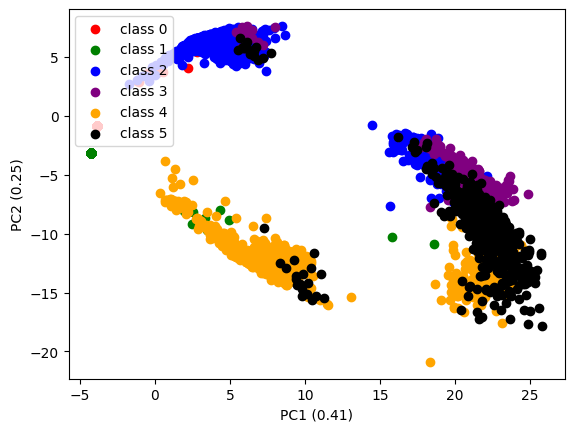

In [27]:
# plot the model predicted class in feature space

## defines amount of clusters
num_classes = 6

## works like range() function for numpy array
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

## loops thru class number
## QUESTION: what exactly is this chunk of code doing? i understand it makes a list and appends things to them based on whether they meet a critera
## however, what is the list's purpose?
for i in classes:
  ## sets value of df as feats_df[True or False] ???
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)

##print("Feats_df[True]:")
##print(feats_df[feats_df["Ua"].astype(float) >= .05])

feat_1 = "pc1"

feat_2 = "pc2"

## figure (window), ax (axes) = plt.subplots object
fig, ax = plt.subplots()

colors = ["red","green","blue","purple","orange","black","pink"]
alpha = [1,1,1,1,1,1,1]
for j in classes:
  # print(j)
  df = class_dfs[j]
  ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


leg = ax.legend(loc="upper left")

ax.set(xlabel = "PC1 (0.41)", ylabel = "PC2 (0.25)", title = "")
plt.show()

## QUESTION: is the .41 and the .25 the percentage of variation
## the data is describing?


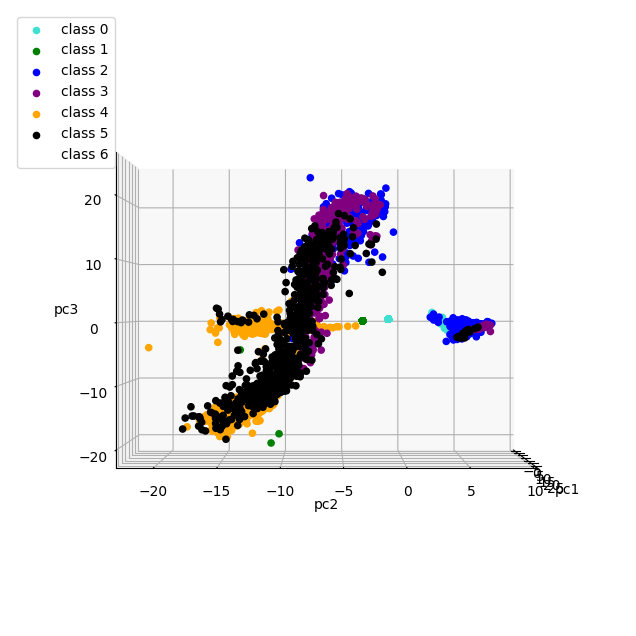

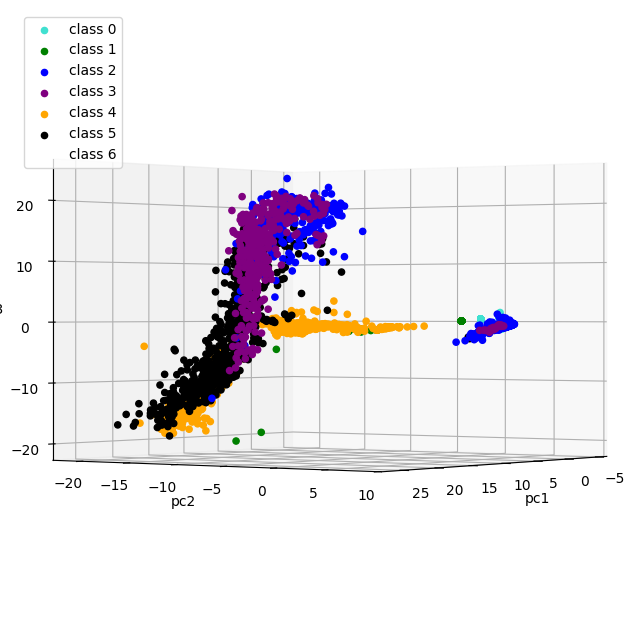

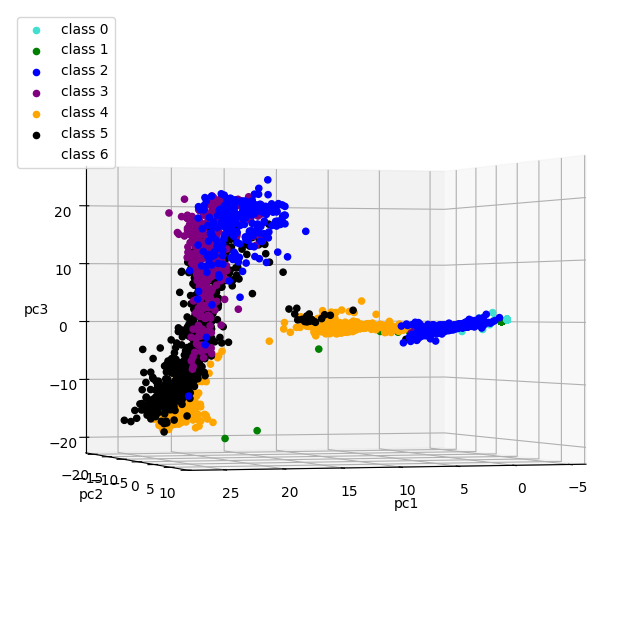

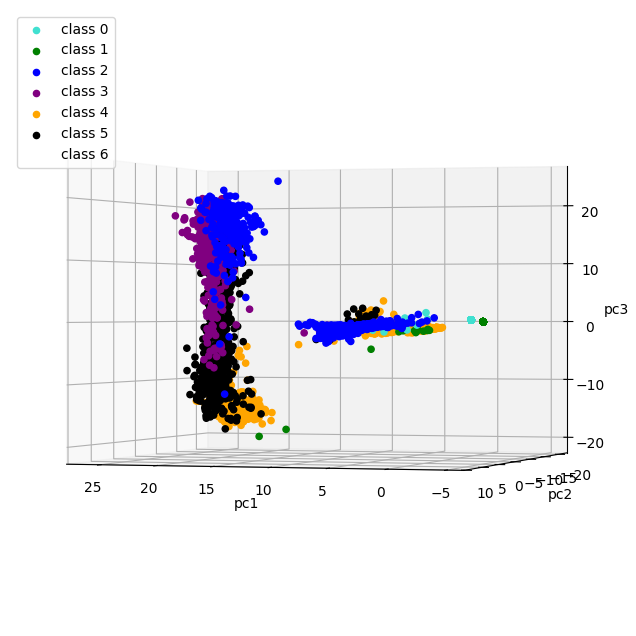

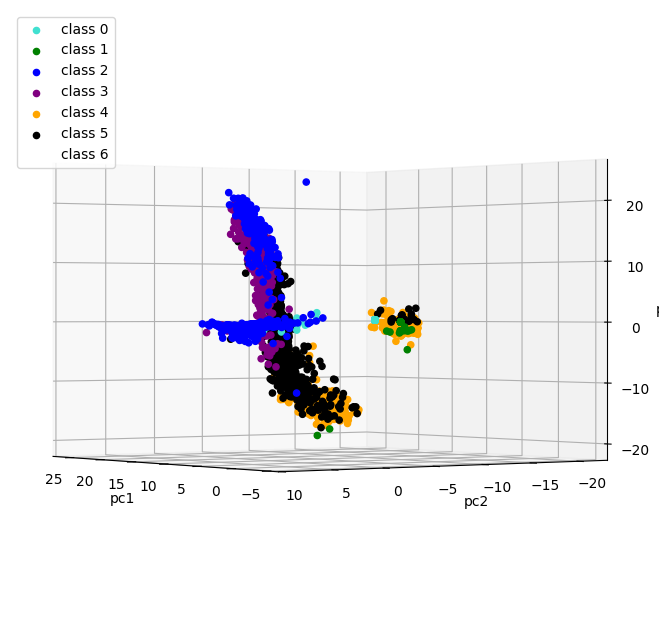

KeyboardInterrupt: 

In [28]:
# do clusters in first 3 PCs

from mpl_toolkits import mplot3d


num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster


for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)

feat_1 = "pc1"

feat_2 = "pc2"

feat_3 = "pc3"

for k in range(10):
  # Creating 3D figure
  fig = plt.figure(figsize=(8, 8))
  ax = plt.axes(projection='3d')

  colors = ["turquoise","green","blue","purple","orange","black","pink"]
  alpha = [1,1,1,1,1,1,0]
  for j in classes:
    df = class_dfs[j]
    ax.scatter3D(df[feat_1], df[feat_2], df[feat_3], c = colors[j], label = "class " + str(j), alpha = alpha[j])


  leg = ax.legend(loc="upper left")

  ax.set(xlabel = feat_1, ylabel = feat_2, zlabel = feat_3)

  # 360 Degree view
  ax.view_init(0, 36*k)


  plt.show()